## 0. Libraries

In [1]:
# Import LoopDetect core and numpy
import numpy as np
import loopdetect.core as ld
import loopdetect.examples as lde
import numdifftools
import pandas as pd

from scipy.integrate import odeint
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

d:\Work\StudentJob\Jana Wolf\LoopDetect_2025\env\lib\loopdetect_python_3.12\Lib\site-packages\loopdetect\examples.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


## 1. Configuration

In [2]:
from matplotlib import rcParams

rcParams.update({
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "mathtext.fontset": "cm",
    "text.usetex": True,  # requires LaTeX installation
    "axes.linewidth": 1.2,
    "axes.labelsize": 18,
    "axes.titlesize": 18,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "legend.fontsize": 14,
    "figure.dpi": 300,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.minor.visible": True,
    "ytick.minor.visible": True,
    "xtick.major.size": 6,
    "xtick.minor.size": 3,
    "ytick.major.size": 6,
    "ytick.minor.size": 3,
    "xtick.major.width": 1.0,
    "ytick.major.width": 1.0,
})

colors = ['#EE7733', '#0077BB', '#33BBEE', '#EE3377', '#CC3311', '#009988', '#BBBBBB']
colors_02 = ['#332288', '#117733', '#DDCC77', '#882255', '#AA4499', '#88CCEE', '#44AA99', '#999933', '#CC6677', '#DDDDDD']

## 2. Main reproduction

#### **Example 7: Repressilators model with cyclic transcriptional repression**

The synthetic genetic oscillator proposed by Michael B. Elowitz and Stanislas Leibler captures the dynamics of a three-gene negative feedback loop constructed in *Escherichia coli* [1]. The network consists of three transcriptional repressors arranged in a cyclic topology such that each gene product inhibits transcription of the next gene in the loop. This model forms a closed negative feedback system without explicit positive feedback. The three transcriptional repressor systems shows oscillating behavior.

Each gene is transcribed into mRNA and subsequently translated into protein. The model contains six dynamic variables: three mRNA concentrations and three corresponding protein concentrations. Transcriptional repression is described by Hill kinetics to account for cooperative binding of repressors to promoter regions. Protein and mRNA degradation are modelled as first-order processes.

$$\frac{dL}{dt} = -k_1 L + k_2 m_L$$

$$\frac{dT}{dt} = -k_3 T + k_4 m_T$$

$$\frac{dC}{dt} = -k_5 C + k_6 m_C$$

$$\frac{dm_L}{dt} = k_7 + k_8 \frac{kn_1^{n_1}}{kn_1^{n_1} + C^{n_1}} - k_9 m_L$$

$$\frac{dm_T}{dt} = k_{10} + k_{11} \frac{kn_2^{n_2}}{kn_2^{n_2} + L^{n_2}} - k_{12} m_T$$

$$\frac{dm_C}{dt} = k_{13} + k_{14} \frac{kn_3^{n_3}}{kn_3^{n_3} + T^{n_3}} - k_{15} m_C$$


with:

$L = \text{LacI protein}$, $T = \text{TetR protein}$, $C = \lambda \text{cl protein}$,

$m_L = \text{LacI mRNA}$, $m_T = \text{TetR mRNA}$, $m_C = \lambda \text{cl mRNA}$

Initial condition values are in the supplement document.

**Reference:**

[1] Elowitz MB, Leibler S (2000) A synthetic oscillatory network of transcriptional regulators. Nature 403: 335–338

### Old function

In [3]:
# function[dx]=func_elo00(t,x,klin,knonlin) %[dx,J]=func_elo00(t,x,klin,knonlin)
#     dx=zeros(6,1);
#     % J=jacob_elo00(t,x,klin,knonlin);
#     dx(1)=-klin(1)*x(1)+klin(2)*x(4); %LacI
#     dx(2)=-klin(3)*x(2)+klin(4)*x(5); %TetR
#     dx(3)=-klin(5)*x(3)+klin(6)*x(6); %lambda cl
#     dx(4)=klin(7)+klin(8)/(knonlin(1)^knonlin(4)+x(3)^knonlin(4))+ ...
#           klin(9)*x(3)^knonlin(4)/(knonlin(1)^knonlin(4)+ ...
#                                    x(3)^knonlin(4))-klin(10)*x(4); %LacI mRNA
#     dx(5)=klin(11)+klin(12)/(knonlin(2)^knonlin(5)+ ...
#                              x(1)^knonlin(5))+klin(13)* ...
#           x(1)^knonlin(5)/(knonlin(2)^knonlin(5)+x(1)^knonlin(5))-klin(14)*x(5); %TetR mRNA
#     dx(6)=klin(15)+klin(16)/(knonlin(3)^knonlin(6)+ ...
#                              x(2)^knonlin(6))+klin(17)* ...
#           x(2)^knonlin(6)/(knonlin(3)^knonlin(6)+x(2)^knonlin(6))- ...
#           klin(18)*x(6); %lambda cl mRNA
    
def func_elo00(x, klin, knonlin):
    dx = np.zeros(6)
    dx[0] = -klin[0] * x[0] + klin[1] * x[3]  # LacI
    dx[1] = -klin[2] * x[1] + klin[3] * x[4]  # TetR
    dx[2] = -klin[4] * x[2] + klin[5] * x[5]  # lambda cl
    dx[3] = klin[6] + klin[7] / (knonlin[0] ** knonlin[3] + x[2] ** knonlin[3]) + \
            klin[8] * x[2] ** knonlin[3] / (knonlin[0] ** knonlin[3] + x[2] ** knonlin[3]) - klin[9] * x[3]  # LacI mRNA
    dx[4] = klin[10] + klin[11] / (knonlin[1] ** knonlin[4] \
            + x[0] ** knonlin[4]) + klin[12] * x[0] ** knonlin[4] / (knonlin[1] ** knonlin[4] \
            + x[0] ** knonlin[4]) - klin[13] * x[4]  # TetR mRNA
    dx[5] = klin[14] + klin[15] / (knonlin[2] ** knonlin[5] + x[1] ** knonlin[5]) \
            + klin[16] * x[1] ** knonlin[5] / (knonlin[2] ** knonlin[5] + x[1] ** knonlin[5]) \
            - klin[17]*x[5] # lambda cl mRNA
    return dx

### Fix function

In [4]:
# function[dx]=func_elo00_fix(t,x,klin,knonlin)
#     dx=zeros(6,1);
#     dx(1)=-klin(1)*x(1)+klin(2)*x(4); %LacI
#     dx(2)=-klin(3)*x(2)+klin(4)*x(5); %TetR
#     dx(3)=-klin(5)*x(3)+klin(6)*x(6); %lambda cl
#     dx(4)=klin(7)+klin(8)*knonlin(1)^knonlin(4)/(knonlin(1)^knonlin(4)+x(3)^knonlin(4))...
#           -klin(9)*x(4); %LacI mRNA
#     dx(5)=klin(10)+klin(11)*knonlin(2)^knonlin(5)/(knonlin(2)^knonlin(5)+x(1)^knonlin(5))... 
#           -klin(12)*x(5); %TetR mRNA
#     dx(6)=klin(13)+klin(14)*knonlin(3)^knonlin(6)/(knonlin(3)^knonlin(6)+x(2)^knonlin(6)) ...
#           -klin(15)*x(6); %lambda cl mRNA
    
def func_elo00_fix(x, klin, knonlin):
    dx = np.zeros(6)
    dx[0] = -klin[0]*x[0]+klin[1]*x[3] #LacI
    dx[1] = -klin[2]*x[1]+klin[3]*x[4] #TetR
    dx[2] = -klin[4]*x[2]+klin[5]*x[5] #lambda cl
    dx[3] = klin[6]+klin[7]*knonlin[0]**knonlin[3]/(knonlin[0]**knonlin[3]+x[2]**knonlin[3]) \
            -klin[8]*x[3] #LacI mRNA
    dx[4] = klin[9]+klin[10]*knonlin[1]**knonlin[4]/(knonlin[1]**knonlin[4]+x[0]**knonlin[4]) \
            -klin[11]*x[4] #TetR mRNA
    dx[5] = klin[12]+klin[13]*knonlin[2]**knonlin[5]/(knonlin[2]**knonlin[5]+x[1]**knonlin[5]) \
            -klin[14]*x[5] #lambda cl mRNA
    return dx

def solve_func_elo00(x0, time_points, klin, knonlin):
    def model(t, x):
        return func_elo00_fix(x, klin, knonlin)
    sol = solve_ivp(model, [time_points[0], time_points[-1]], x0,
                    t_eval=time_points, method='RK45', rtol=1e-6)
    return sol

In [5]:
# Parameters from supplementary material
# Parameters Elowitz repressilator
beta0 = 0.0012
beta1 = 0.1155
alpha0 = 5*1e-4
alpha1 = 0.5
k1=0.0058
klin=[beta0, beta1, beta0, beta1, beta0, beta1, #beta1: protein production, beta0: protein degradation
    alpha0, alpha1, k1, alpha0, alpha1, k1, alpha0, alpha1, k1] #alpha0, alpha1: mRNA production; k1: mRNA degradation
knonlin=[40,40,40,2,2,2] #KM:inhibition constants, n: inhibition Hill coefficient
#Initial conditions Elowitz repressilator
s_ini_elo = np.zeros(6)
s_ini_elo[4]=1

labels = ['LacI', 'TetR', u'λ cl', 'LacI mRNA', 'TetR mRNA', u'λ cl mRNA']
plot_labels = ["LacI", "TetR", u"$\lambda$ cl", 'LacI mRNA', 'TetR mRNA', u'$\lambda$ cl mRNA']

<>:16: SyntaxWarning: invalid escape sequence '\l'
<>:16: SyntaxWarning: invalid escape sequence '\l'
<>:16: SyntaxWarning: invalid escape sequence '\l'
<>:16: SyntaxWarning: invalid escape sequence '\l'
C:\Users\Admin\AppData\Local\Temp\ipykernel_22960\82316660.py:16: SyntaxWarning: invalid escape sequence '\l'
  plot_labels = ["LacI", "TetR", u"$\lambda$ cl", 'LacI mRNA', 'TetR mRNA', u'$\lambda$ cl mRNA']
C:\Users\Admin\AppData\Local\Temp\ipykernel_22960\82316660.py:16: SyntaxWarning: invalid escape sequence '\l'
  plot_labels = ["LacI", "TetR", u"$\lambda$ cl", 'LacI mRNA', 'TetR mRNA', u'$\lambda$ cl mRNA']


### Temporal dynamics

In [6]:
time_points = np.linspace(0, 40900, 40901)
sol = solve_func_elo00(s_ini_elo, time_points, klin, knonlin)

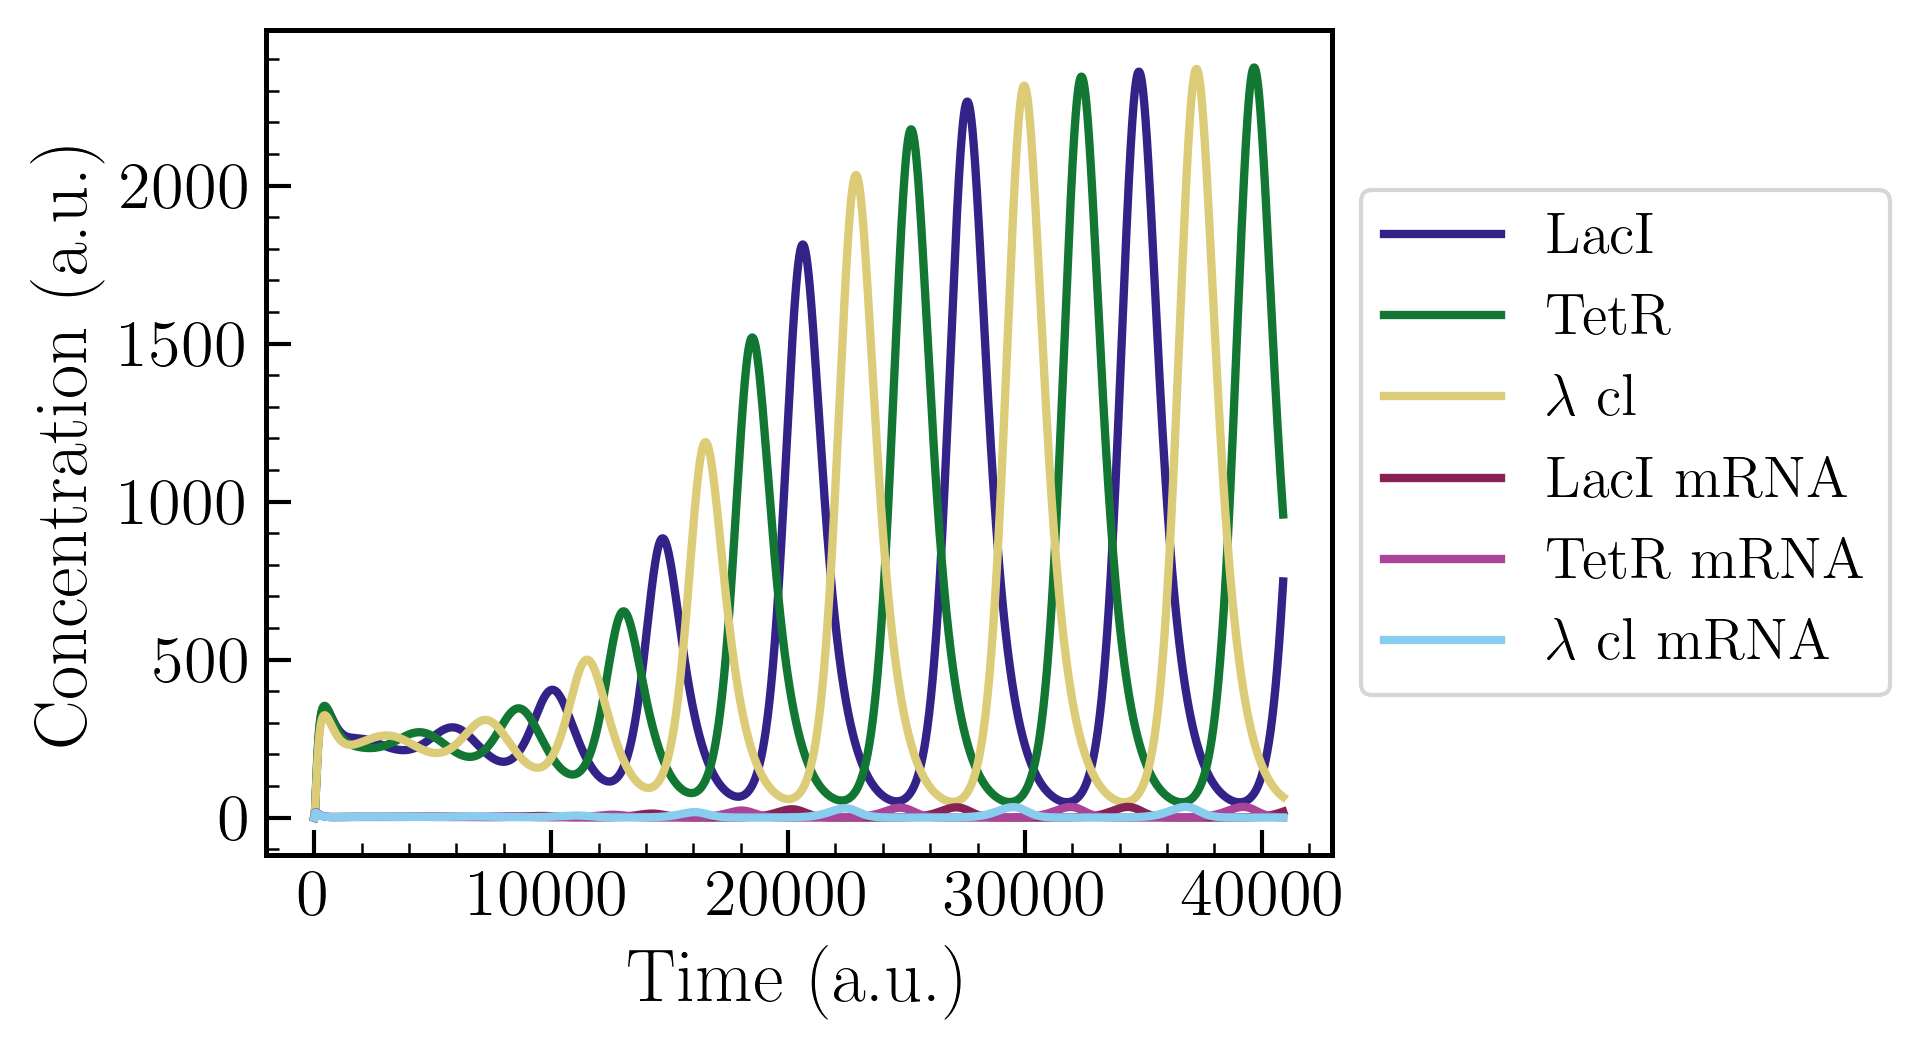

In [7]:
plt.figure(figsize=(6.5, 3.6)) 
for i, c in enumerate(colors_02[:6]):
    plt.plot(time_points, sol.y[i], lw=2, color=c)
# plt.axvline(x=0.2, color='black', linestyle='--', lw=1.5, alpha=0.7)
# plt.xlim(0, 1)
plt.xlabel('Time (a.u.)')
plt.ylabel('Concentration (a.u.)')
# plt.title('Concentration vs Time for Complex Formation Model')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), labels=plot_labels) # , 'LacI mRNA', 'TetR mRNA', 'λ cl mRNA'
# plt.legend()
plt.tight_layout()
# plt.savefig("figure_model2_complex_formation.svg")
plt.show()

Now, when the system have stable trajectories, draw temporal dynamics for t=[0, 50000].

In [8]:
sol.y[:,-1]

array([7.47387498e+02, 9.59115830e+02, 6.54054017e+01, 1.88972300e+01,
       7.30090934e-01, 1.95398879e-01])

In [7]:
time_points_stable = np.linspace(0, 50000, 50001)
sol_2 = solve_func_elo00(sol.y[:,-1], time_points_stable, klin, knonlin)

In [10]:
investigate_index = [1, 2, 0]
investigate_labels = [plot_labels[x] for x in investigate_index]
investigate_labels

['TetR', '$\\lambda$ cl', 'LacI']

<>:11: SyntaxWarning: invalid escape sequence '\l'
<>:11: SyntaxWarning: invalid escape sequence '\l'
C:\Users\Admin\AppData\Local\Temp\ipykernel_24560\258099731.py:11: SyntaxWarning: invalid escape sequence '\l'
  plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), labels=['TetR', '$\lambda$ cl', 'LacI'])


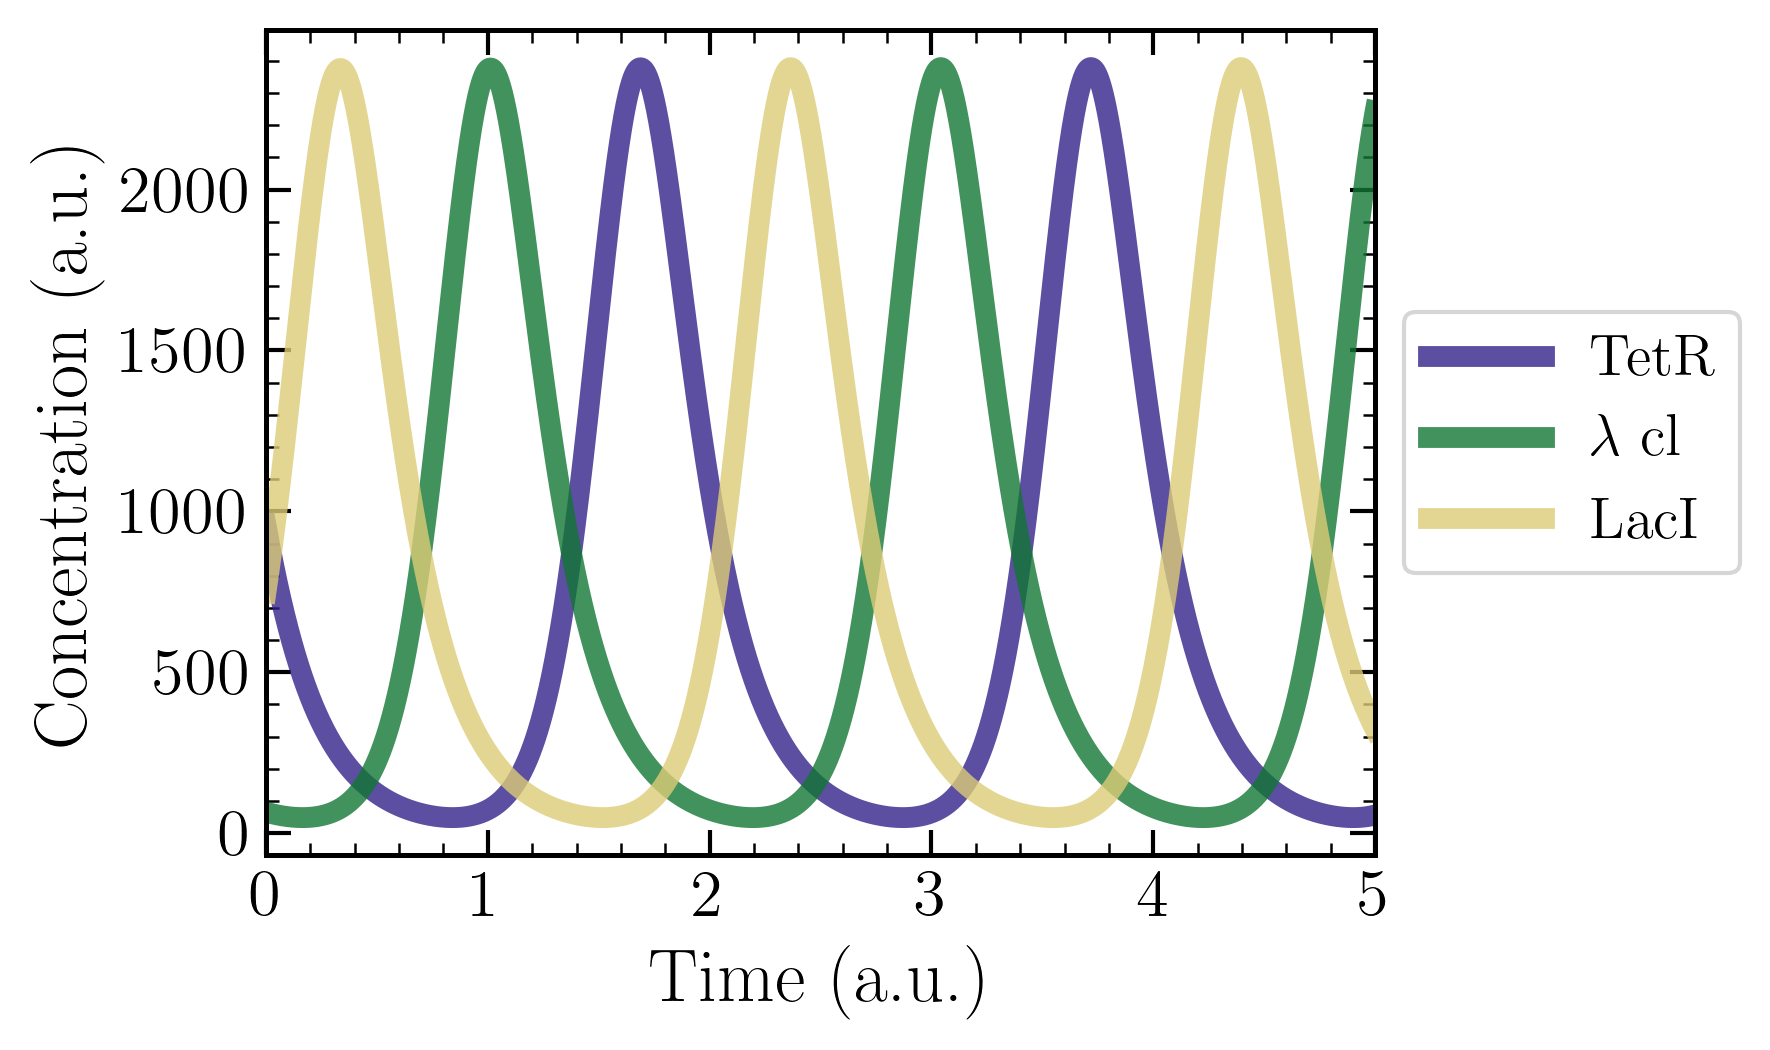

In [14]:
investigate_index = [1, 2, 0]
investigate_labels = [labels[x] for x in investigate_index]
plt.figure(figsize=(6, 3.6)) 
for i in range(len(investigate_index)):
    plt.plot(time_points_stable/3600, sol_2.y[investigate_index[i]], lw=5, color=colors_02[i], alpha=0.8)
plt.xlim([0,5])
plt.xlabel('Time (a.u.)')
plt.ylabel('Concentration (a.u.)')
plt.gca().yaxis.set_ticks_position('both')
plt.gca().xaxis.set_ticks_position('both')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), labels=['TetR', '$\lambda$ cl', 'LacI'])
plt.tight_layout()
plt.savefig("img/figure_model7_Repressilator_protein.svg", dpi=300)
plt.show()


In [16]:
investigate_index_2 = [4, 5, 3]
investigate_labels_2 = [plot_labels[x] for x in investigate_index_2]
investigate_labels_2

['TetR mRNA', '$\\lambda$ cl mRNA', 'LacI mRNA']

<>:9: SyntaxWarning: invalid escape sequence '\l'
<>:9: SyntaxWarning: invalid escape sequence '\l'
C:\Users\Admin\AppData\Local\Temp\ipykernel_24560\269758012.py:9: SyntaxWarning: invalid escape sequence '\l'
  plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), labels=['TetR mRNA', '$\lambda$ cl mRNA', 'LacI mRNA'])


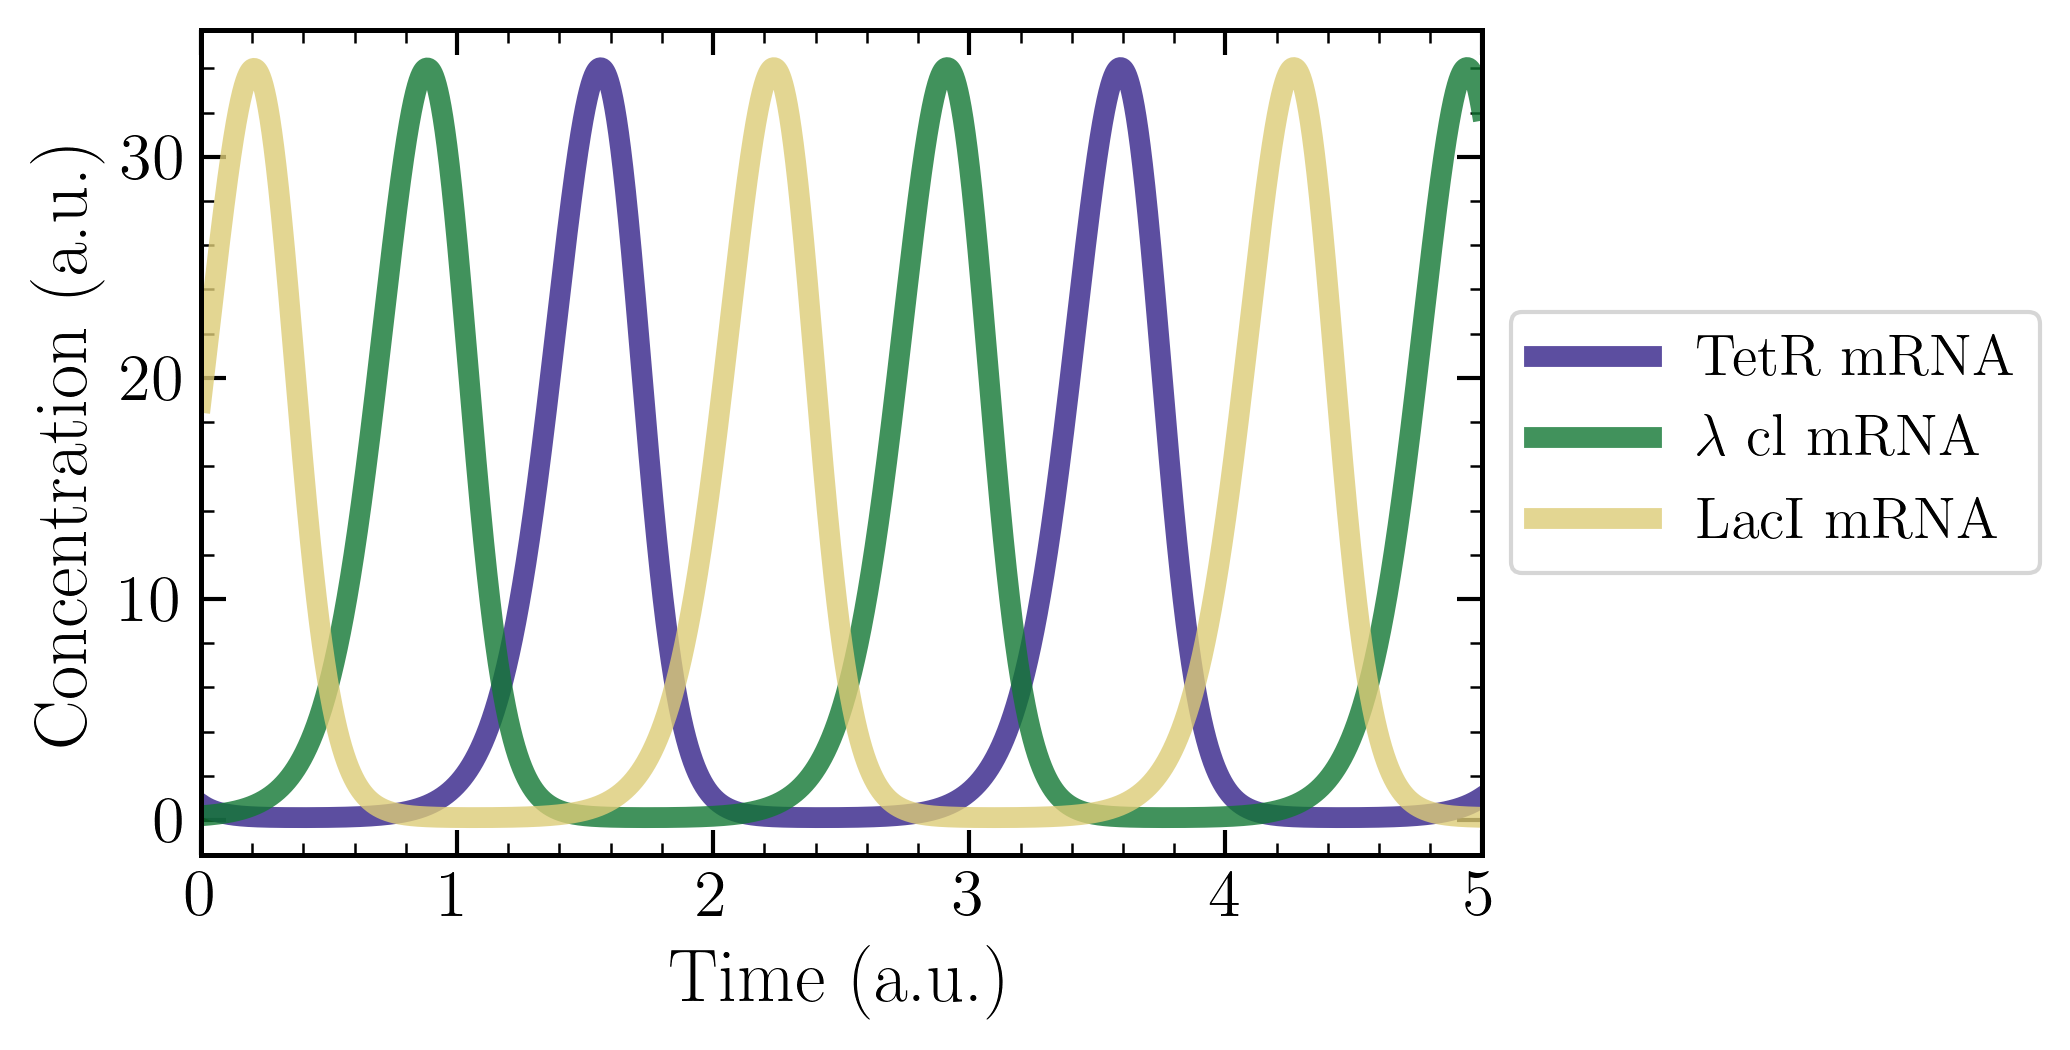

In [18]:
plt.figure(figsize=(7, 3.6)) 
for i in range(len(investigate_index_2)):
    plt.plot(time_points_stable/3600, sol_2.y[investigate_index_2[i]], lw=5, color=colors_02[i], alpha=0.8)
plt.xlim([0,5])
plt.xlabel('Time (a.u.)')
plt.ylabel('Concentration (a.u.)')
plt.gca().yaxis.set_ticks_position('both')
plt.gca().xaxis.set_ticks_position('both')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), labels=['TetR mRNA', '$\lambda$ cl mRNA', 'LacI mRNA'])
plt.tight_layout()
plt.savefig("img/figure_model7_Repressilator_mRNA.svg", dpi=300)
# plt.show()


<>:9: SyntaxWarning: invalid escape sequence '\l'
<>:16: SyntaxWarning: invalid escape sequence '\l'
<>:9: SyntaxWarning: invalid escape sequence '\l'
<>:16: SyntaxWarning: invalid escape sequence '\l'
C:\Users\Admin\AppData\Local\Temp\ipykernel_24560\443182289.py:9: SyntaxWarning: invalid escape sequence '\l'
  axs[0].legend(loc='center left', bbox_to_anchor=(1, 0.5), labels=['TetR', '$\lambda$ cl', 'LacI'])
C:\Users\Admin\AppData\Local\Temp\ipykernel_24560\443182289.py:16: SyntaxWarning: invalid escape sequence '\l'
  axs[1].legend(loc='center left', bbox_to_anchor=(1, 0.5), labels=['TetR mRNA', '$\lambda$ cl mRNA', 'LacI mRNA'])


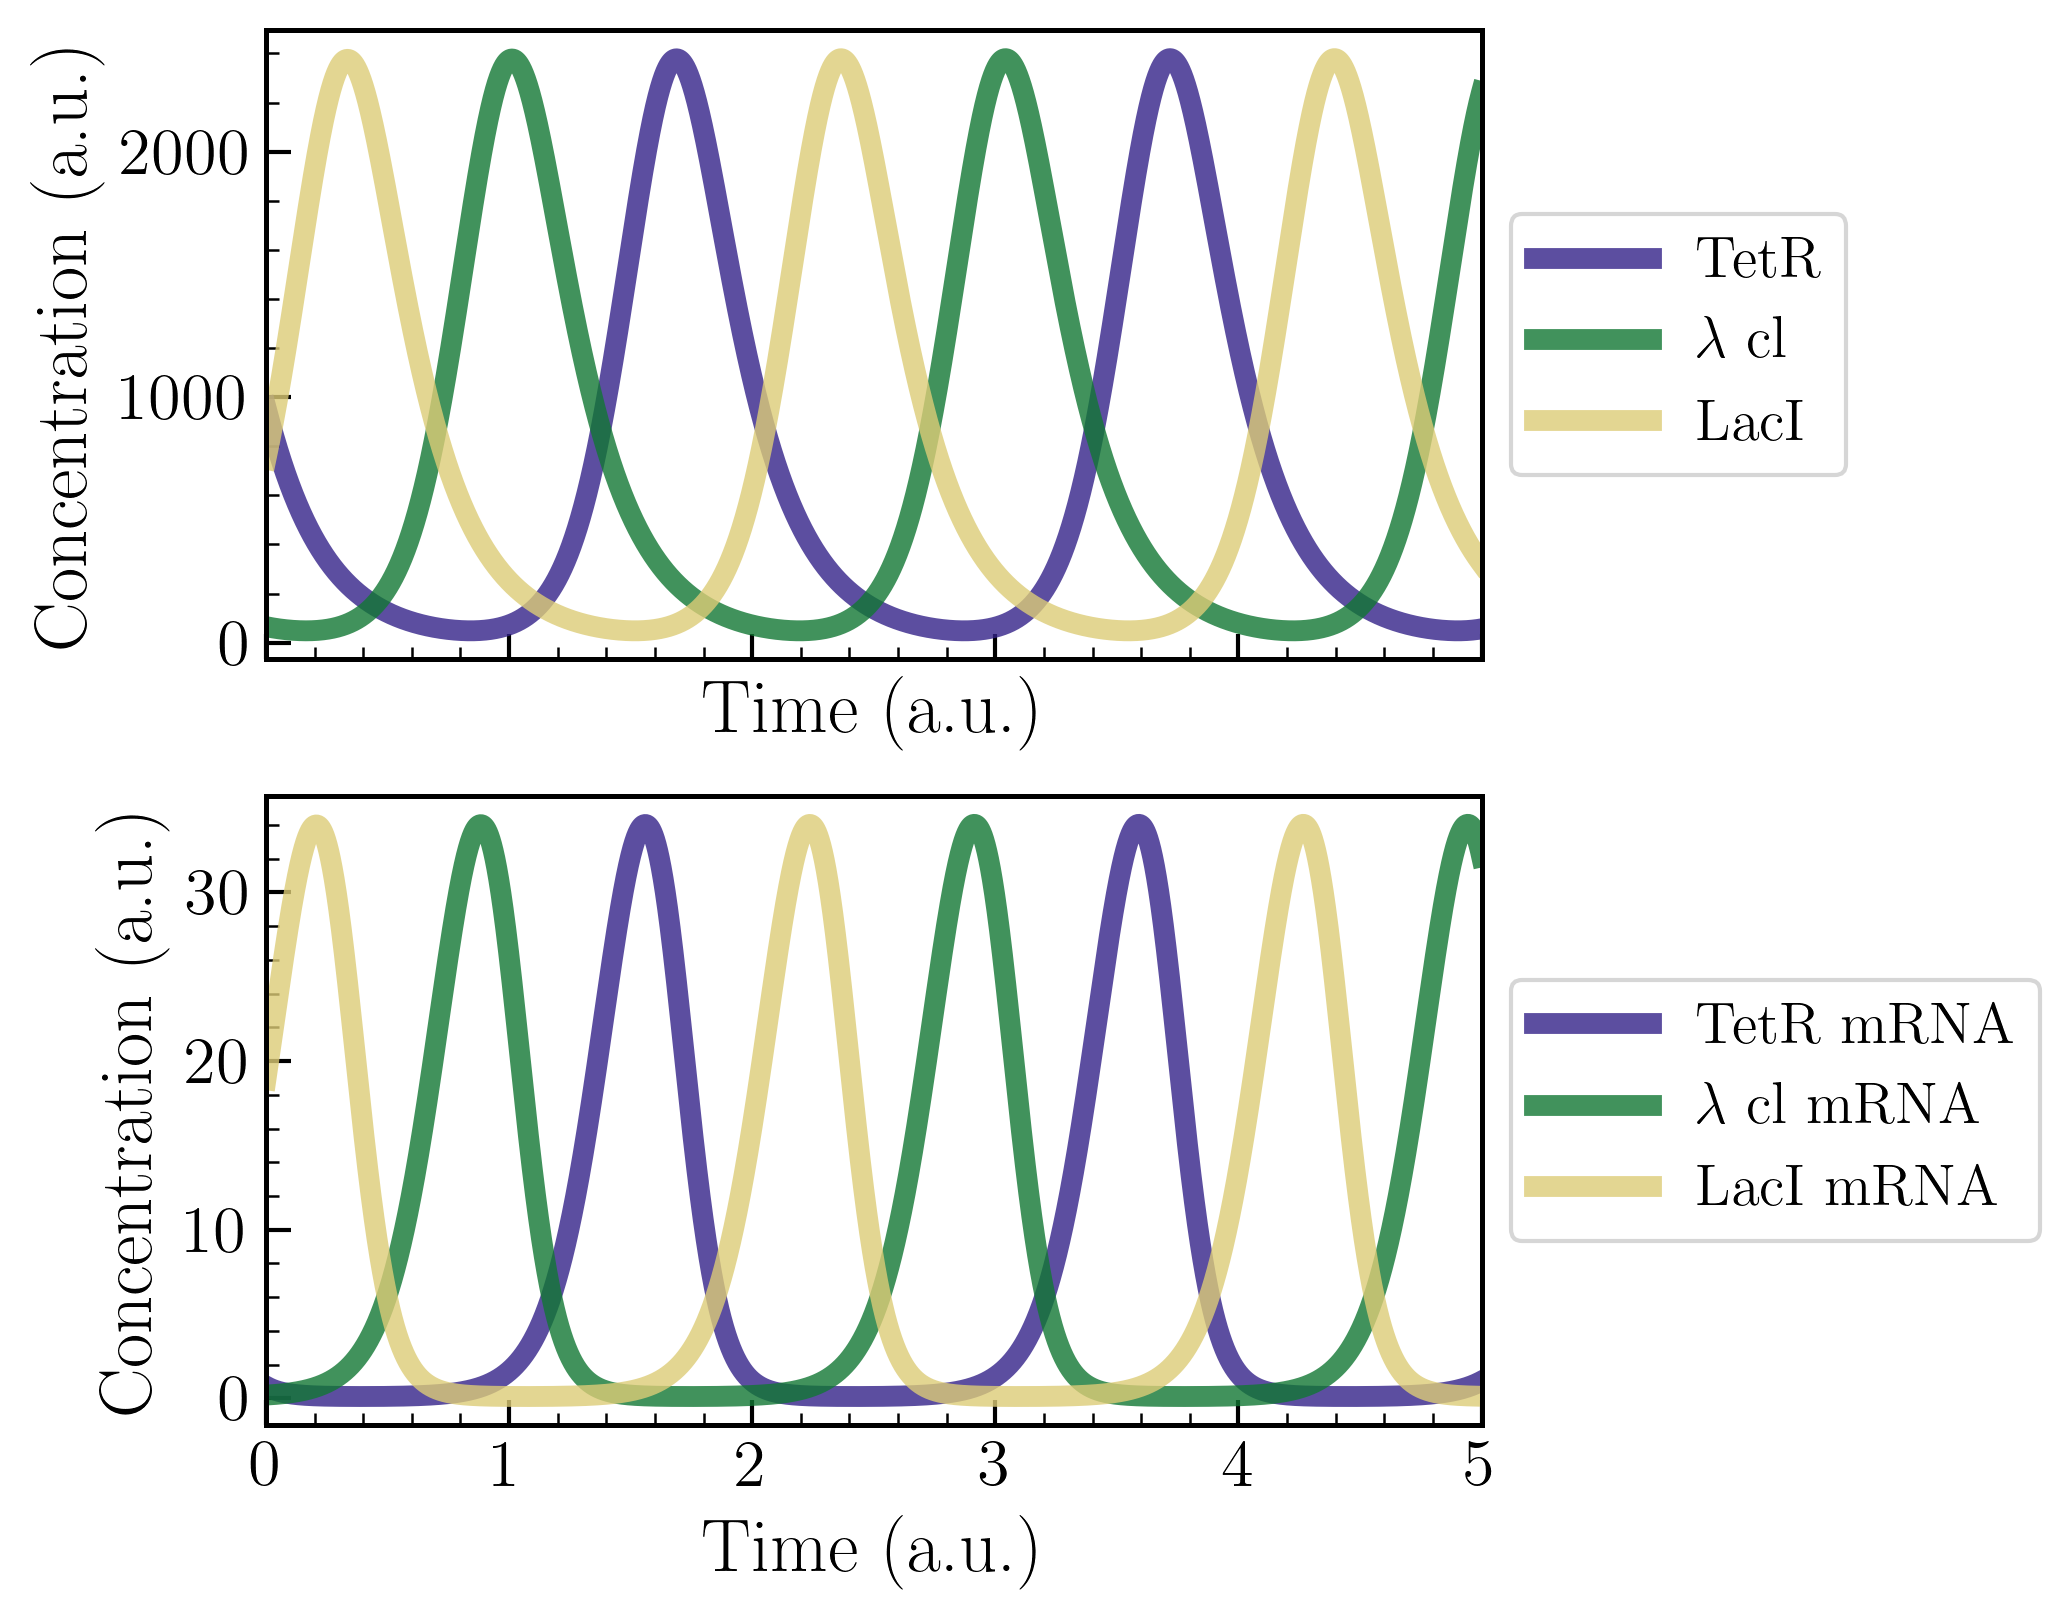

In [24]:
# Create a plot with 2 subplots (2 rows, 1 column) for the 2 above investigated groups
fig, axs = plt.subplots(2, 1, figsize=(7, 5.5), sharex=True)
# First subplot for proteins
for i in range(len(investigate_index)):
    axs[0].plot(time_points_stable/3600, sol_2.y[investigate_index[i]], lw=5, color=colors_02[i], alpha=0.8)
axs[0].set_xlim([0,5])
axs[0].set_xlabel('Time (a.u.)')
axs[0].set_ylabel('Concentration (a.u.)')
axs[0].legend(loc='center left', bbox_to_anchor=(1, 0.5), labels=['TetR', '$\lambda$ cl', 'LacI'])
# Second subplot for mRNAs
for i in range(len(investigate_index_2)):
    axs[1].plot(time_points_stable/3600, sol_2.y[investigate_index_2[i]], lw=5, color=colors_02[i], alpha=0.8)
axs[1].set_xlim([0,5])
axs[1].set_xlabel('Time (a.u.)')
axs[1].set_ylabel('Concentration (a.u.)')
axs[1].legend(loc='center left', bbox_to_anchor=(1, 0.5), labels=['TetR mRNA', '$\lambda$ cl mRNA', 'LacI mRNA'])
plt.tight_layout()
plt.savefig("img/figure_model7_Repressilator_protein_mRNA.svg", dpi=300)
plt.show()

In [8]:
# Loop detect
res_tab_complex = ld.find_loops_vset(func_elo00_fix, 
                                     vset=[sol.y[:, -1]], 
                                     klin=klin,
                                     knonlin=knonlin 
                                     ) # max_num_loops=10
print(res_tab_complex['loop_rep'][0])
ld.loop_summary(res_tab_complex['loop_rep'][0])

                    loop  length  sign
0  (0, 4, 1, 5, 2, 3, 0)       6    -1
1                 (0, 0)       1    -1
2                 (1, 1)       1    -1
3                 (2, 2)       1    -1
4                 (3, 3)       1    -1
5                 (4, 4)       1    -1
6                 (5, 5)       1    -1


length,1,6
total,6,1
neg,6,1
pos,0,0


In [9]:
# Loop detect
res_tab_complex = ld.find_loops_vset(func_elo00_fix, 
                                     vset=[sol_2.y[:, -1]], 
                                     klin=klin,
                                     knonlin=knonlin 
                                     ) # max_num_loops=10
print(res_tab_complex['loop_rep'][0])
ld.loop_summary(res_tab_complex['loop_rep'][0])

                    loop  length  sign
0  (0, 4, 1, 5, 2, 3, 0)       6    -1
1                 (0, 0)       1    -1
2                 (1, 1)       1    -1
3                 (2, 2)       1    -1
4                 (3, 3)       1    -1
5                 (4, 4)       1    -1
6                 (5, 5)       1    -1


length,1,6
total,6,1
neg,6,1
pos,0,0


In [27]:
# Loop detect
res_tab_complex = ld.find_loops_vset(func_elo00_fix, 
                                     vset=list(sol_2.y.T), 
                                     klin=klin,
                                     knonlin=knonlin 
                                     ) # max_num_loops=10
print(res_tab_complex['loop_rep'][0])
ld.loop_summary(res_tab_complex['loop_rep'][0])

                    loop  length  sign
0  (0, 4, 1, 5, 2, 3, 0)       6    -1
1                 (0, 0)       1    -1
2                 (1, 1)       1    -1
3                 (2, 2)       1    -1
4                 (3, 3)       1    -1
5                 (4, 4)       1    -1
6                 (5, 5)       1    -1


length,1,6
total,6,1
neg,6,1
pos,0,0


In [11]:
id_to_subject = {
    0: 'LacI',
    1: 'TetR',
    2: 'lambda cl',
    3: 'LacI mRNA',
    4: 'TetR mRNA',
    5: 'lambda cl mRNA'
}

df = pd.DataFrame(res_tab_complex['loop_rep'][0]).sort_values(by=['length','loop'])

df["loop_subject"] = df["loop"].apply(
    lambda t: tuple(id_to_subject[i] for i in t)
)
pd.options.display.max_colwidth = 100
df

,loop,length,sign,loop_subject
1,"(0, 0)",1,-1,"(LacI, LacI)"
2,"(1, 1)",1,-1,"(TetR, TetR)"
3,"(2, 2)",1,-1,"(lambda cl, lambda cl)"
4,"(3, 3)",1,-1,"(LacI mRNA, LacI mRNA)"
5,"(4, 4)",1,-1,"(TetR mRNA, TetR mRNA)"
6,"(5, 5)",1,-1,"(lambda cl mRNA, lambda cl mRNA)"
0,"(0, 4, 1, 5, 2, 3, 0)",6,-1,"(LacI, TetR mRNA, TetR, lambda cl mRNA, lambda cl, LacI mRNA, LacI)"


In [28]:
res_tab_complex

{'jac_rep': [array([[-1.,  0.,  0.,  1.,  0.,  0.],
         [ 0., -1.,  0.,  0.,  1.,  0.],
         [ 0.,  0., -1.,  0.,  0.,  1.],
         [ 0.,  0., -1., -1.,  0.,  0.],
         [-1.,  0.,  0.,  0., -1.,  0.],
         [ 0., -1.,  0.,  0.,  0., -1.]])],
 'jac_rep_index': array([0, 0, 0, ..., 0, 0, 0], shape=(50001,)),
 'loop_rep': [                    loop  length  sign
  0  (0, 4, 1, 5, 2, 3, 0)       6    -1
  1                 (0, 0)       1    -1
  2                 (1, 1)       1    -1
  3                 (2, 2)       1    -1
  4                 (3, 3)       1    -1
  5                 (4, 4)       1    -1
  6                 (5, 5)       1    -1],
 'loop_rep_index': array([0, 0, 0, ..., 0, 0, 0], shape=(50001,))}

In [30]:
# Turn the signed Jacobian into a DataFrame for better visualization
signed_jacobian_df = pd.DataFrame(res_tab_complex['jac_rep'][0], index=labels, columns=labels)
signed_jacobian_df

,LacI,TetR,λ cl,LacI mRNA,TetR mRNA,λ cl mRNA
LacI,-1.0,0.0,0.0,1.0,0.0,0.0
TetR,0.0,-1.0,0.0,0.0,1.0,0.0
λ cl,0.0,0.0,-1.0,0.0,0.0,1.0
LacI mRNA,0.0,0.0,-1.0,-1.0,0.0,0.0
TetR mRNA,-1.0,0.0,0.0,0.0,-1.0,0.0
λ cl mRNA,0.0,-1.0,0.0,0.0,0.0,-1.0


In [31]:
signed_jacobian = res_tab_complex['jac_rep'][0]

In [32]:
# Dataframe with columns: 'from', 'to', 'regulation'
# Apply id to subject mapping

regulation_info = pd.DataFrame(signed_jacobian, columns=[labels[i] for i in range(signed_jacobian.shape[1])], index=[labels[i] for i in range(signed_jacobian.shape[0])])
regulation_info = regulation_info.stack().reset_index()
regulation_info.columns = ['to', 'from', 'regulation']

# Add regulation information for each variable (-1: inhibition (negative), 1:activation (posotive)). 0 means no regulation and will not be shown in the graph.
regulation_info['regulation_words'] = regulation_info['regulation'].map({-1: 'inhibition (negative)', 1: 'activation (positive)', 0: 'no regulation'})
regulation_info

,to,from,regulation,regulation_words
0,LacI,LacI,-1.0,inhibition (negative)
1,LacI,TetR,0.0,no regulation
2,LacI,λ cl,0.0,no regulation
3,LacI,LacI mRNA,1.0,activation (positive)
4,LacI,TetR mRNA,0.0,no regulation
5,LacI,λ cl mRNA,0.0,no regulation
6,TetR,LacI,0.0,no regulation
7,TetR,TetR,-1.0,inhibition (negative)
8,TetR,λ cl,0.0,no regulation
9,TetR,LacI mRNA,0.0,no regulation


In [ ]:
# Extract index from df
df['index'] = df.index

In [ ]:
# Create reverse interaction 
reverse_interaction_list = []
for _, row in loop_data.iterrows():
    loop = row['loop']
    for i in range(len(loop)):
        from_id = loop[i]
        to_id = loop[(i + 1) % len(loop)]  # Wrap around to create a loop
        regulation = signed_jacobian[to_id, from_id]
        reverse_interaction_list.append({
            'from': id_to_subject[from_id],
            'to': id_to_subject[to_id],
            'regulation': regulation,
            'regulation_words': regulation_info[
                (regulation_info['from'] == id_to_subject[to_id]) &
                (regulation_info['to'] == id_to_subject[from_id])
            ]['regulation_words'].values[0]
        })
reverse_interaction_df = pd.DataFrame(reverse_interaction_list)
reverse_interaction_df